In [297]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from itertools import combinations_with_replacement
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

### Задание 3. Адекватность ###

In [298]:
# === Загрузка данных ===
file_path = 'ls_variants.xls'
data = pd.read_excel(file_path, sheet_name="вар. 6")
X = data.iloc[:, 0].values
y = data.iloc[:, 1].values

# === Преобразование признаков ===
X_min = np.min(X)
X_max = np.max(X)
t = 2 * np.pi * (X - X_min) / (X_max - X_min)
num_harmonics = 5
poly_degree = 4

alpha = 0.05  # уровень значимости

XX = np.column_stack([X**d for d in range(poly_degree + 1)] +
                     [np.cos(n * t) for n in range(1, num_harmonics + 1)] +
                     [np.sin(n * t) for n in range(1, num_harmonics + 1)])
XX = XX[:, [True,  True,  True,  True, True, True,  True, False, False,  True,  True,  True, True,  True,  True]]
X_with_const = sm.add_constant(XX)

Функция МНК

In [299]:
def linear_regression_mnk(X, y):
    b = np.linalg.inv(X.T @ X) @ X.T @ y
    Y = X @ b
    e = y - Y
    S = np.sum(e**2)
    n, m = X.shape
    sigma_squared = S / (n - m)
    return b, Y, e, S, sigma_squared, n, m

b, Y_pred, e, S, sigma2, n, m = linear_regression_mnk(X_with_const, y)

Проверка постоянства математического ожидания (ANOVA)

ANOVA (с учетом m): F = 1.709, p = 0.1031
→ Не отклоняем H₀: математическое ожидание ошибок можно считать постоянным.


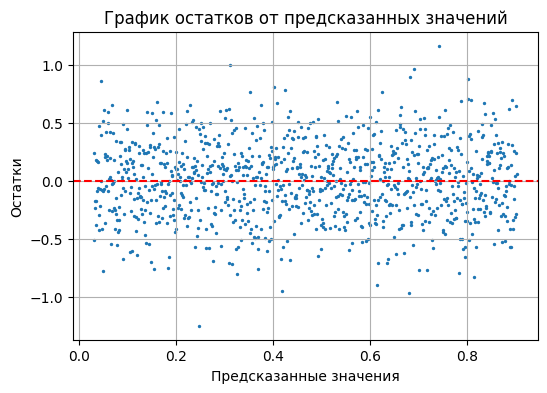

In [300]:
def check_mean_constancy(e, x, m, k=5):
    df = pd.DataFrame({'e': e, 'x': x})
    df = df.sort_values('x')
    df['group'] = pd.qcut(df['x'], q=k, labels=False)

    # Группы и статистики
    group_means = df.groupby('group')['e'].mean()
    e_global_mean = df['e'].mean()
    
    # Межгрупповая сумма квадратов (S0)
    S0 = sum(len(df[df['group'] == j]) * (group_means[j] - e_global_mean)**2 for j in range(k))
    
    # Внутригрупповая сумма квадратов (S)
    S = sum((row['e'] - group_means[row['group']])**2 for _, row in df.iterrows())

    # Статистика F-критерия
    df1 = k - m
    df2 = len(e) - k
    F = (S0 / df1) / (S / df2)
    p_value = 1 - stats.f.cdf(F, df1, df2)

    return F, p_value

f_stat, p_anova = check_mean_constancy(e, X, m=m, k=20)

print(f"ANOVA (с учетом m): F = {f_stat:.3f}, p = {p_anova:.4f}")
if p_anova < alpha:
    print("→ Отклоняем H₀: математическое ожидание ошибок не является постоянным.")
else:
    print("→ Не отклоняем H₀: математическое ожидание ошибок можно считать постоянным.")


plt.figure(figsize=(6, 4))
plt.scatter(X, e, s=2)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("График остатков от предсказанных значений")
plt.grid(True)
plt.show()

Тест Уайта

Обусловленность матрицы признаков до фильтрации: 5.830975893879702e+17


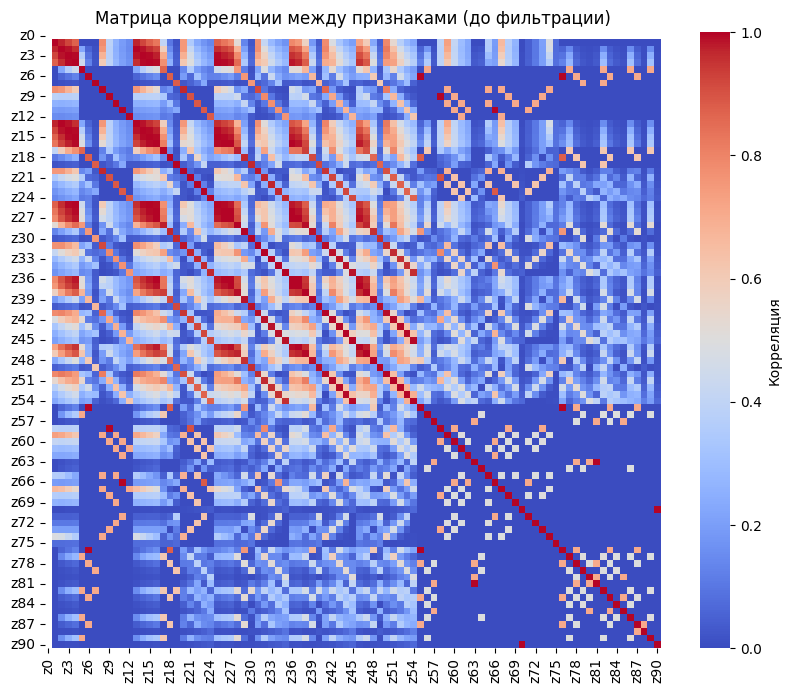

Удалено 77 признаков с корреляцией > 0.7
Осталось признаков: 14 из 91


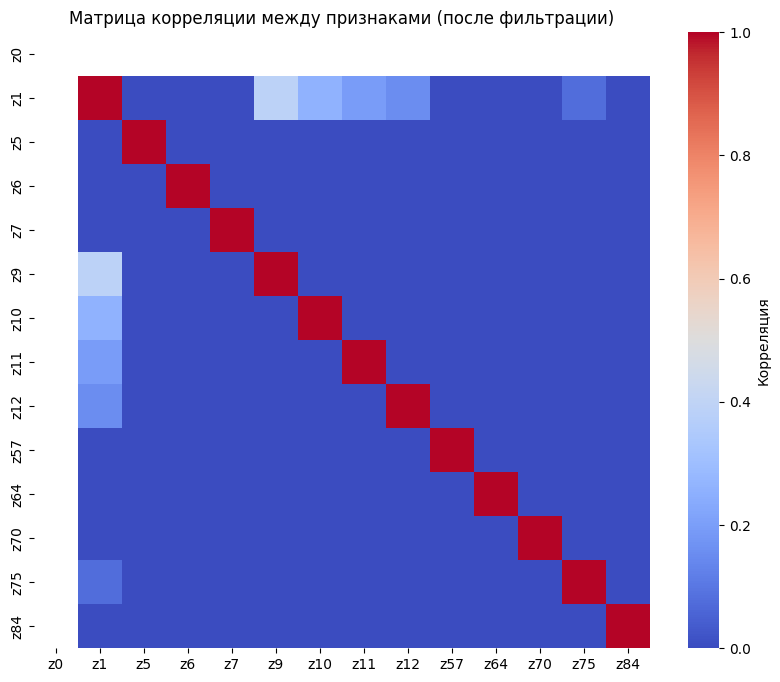

Обусловленность матрицы признаков после фильтрации: 6.558292614032663
White test: LM = 14.412, p = 0.4195
→ Не отклоняем H₀: дисперсия ошибок может считаться постоянной.


In [301]:
def white_test(e, X, threshold=0.7, show_corr=True):
    e2 = e**2

    features = [X[:, i] * X[:, j] for i, j in combinations_with_replacement(range(X.shape[1]), 2)]
    Z_full = np.column_stack(features)
    df_z = pd.DataFrame(Z_full, columns=[f'z{i}' for i in range(Z_full.shape[1])])
    print("Обусловленность матрицы признаков до фильтрации:", np.linalg.cond(Z_full))

    if show_corr:
        corr_before = df_z.corr().abs()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_before, cmap='coolwarm', square=True, cbar_kws={'label': 'Корреляция'})
        plt.title("Матрица корреляции между признаками (до фильтрации)")
        plt.show()

    upper = df_z.corr().abs().where(np.triu(np.ones(df_z.shape[1]), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    df_filtered = df_z.drop(columns=to_drop)
    Z = df_filtered.values

    print(f"Удалено {len(to_drop)} признаков с корреляцией > {threshold}")
    print(f"Осталось признаков: {Z.shape[1]} из {Z_full.shape[1]}")
    
    if show_corr:
        corr_after = df_filtered.corr().abs()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_after, cmap='coolwarm', square=True, cbar_kws={'label': 'Корреляция'})
        plt.title("Матрица корреляции между признаками (после фильтрации)")
        plt.show()

    print("Обусловленность матрицы признаков после фильтрации:", np.linalg.cond(Z))
    
    model = sm.OLS(e2, Z).fit()
    R2 = model.rsquared
    LM = len(e) * R2
    df = Z.shape[1]
    p_value = 1 - stats.chi2.cdf(LM, df)

    return LM, p_value

LM_white, p_white = white_test(e, X_with_const)

print(f"White test: LM = {LM_white:.3f}, p = {p_white:.4f}")
if p_white < alpha:
    print("→ Отклоняем H₀: дисперсия ошибок непостоянна (признак гетероскедастичности).")
else:
    print("→ Не отклоняем H₀: дисперсия ошибок может считаться постоянной.")



Тест Голдфелда–Куандта

In [302]:
def goldfeld_quandt_test(Y, X, split_var_index=1):
    df = pd.DataFrame(X)
    df['Y'] = Y
    df = df.sort_values(by=split_var_index)
    
    n = len(df)
    m = X.shape[1]  # количество регрессоров (включая константу, если есть)
    
    # Обрезаем среднюю часть (примерно n/4)
    drop_n = n // 4
    lower = df.iloc[:(n//2 - drop_n//2)]
    upper = df.iloc[-(n//2 - drop_n//2):]

    # Строим регрессии по двум частям
    model1 = sm.OLS(lower['Y'], sm.add_constant(lower.drop(columns='Y'))).fit()
    model2 = sm.OLS(upper['Y'], sm.add_constant(upper.drop(columns='Y'))).fit()

    # Остаточные суммы квадратов
    RSS1 = model1.ssr
    RSS2 = model2.ssr

    # Размер выборок
    n1 = model1.nobs
    n2 = model2.nobs

    # F-статистика с учетом числа параметров m
    F = (RSS1 / (n1 - m)) / (RSS2 / (n2 - m))
    df1 = n1 - m
    df2 = n2 - m
    p_value = 1 - stats.f.cdf(F, df1, df2)

    return F, p_value

# Пример вызова
F_gq, p_gq = goldfeld_quandt_test(y, X_with_const)
print(f"Goldfeld–Quandt test: F = {F_gq:.3f}, p = {p_gq:.4f}")
if p_gq < alpha:
    print("→ Отклоняем H₀: ошибки имеют различную дисперсию в разных частях выборки.")
else:
    print("→ Не отклоняем H₀: дисперсия ошибок одинакова.\n")

Goldfeld–Quandt test: F = 0.953, p = 0.6786
→ Не отклоняем H₀: дисперсия ошибок одинакова.



Критерий Льюнга–Бокса

Ljung–Box test:
Q = 49.792 
df = 37 
p = 0.0779
не отклоняем H₀: автокорреляция остатков не выявлена.


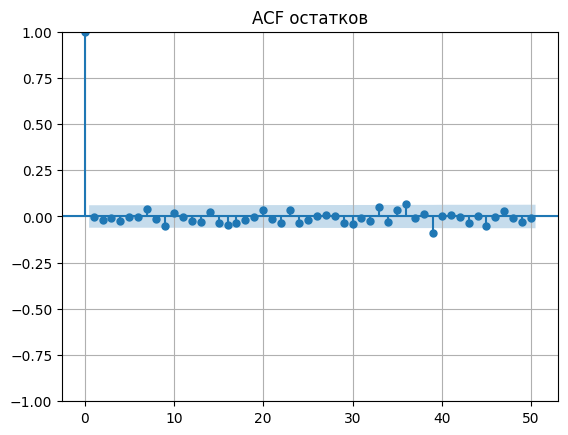

In [303]:
def ljung_box_test(e, lags=20, m=1, alpha=0.05, plot=True):
    n = len(e)
    acf_vals = acf(e, nlags=lags, fft=False)[1:]  # исключаем лаг 0

    # Расчёт статистики Q
    Q = np.sum([(n * (n + 2) * (acf_vals[k] ** 2)) / (n - (k + 1)) for k in range(lags)])
    df = max(lags - m, 1)  # корректировка степеней свободы
    p_value = 1 - stats.chi2.cdf(Q, df)

    print(f"Ljung–Box test:\nQ = {Q:.3f} \ndf = {df} \np = {p_value:.4f}")
    if p_value < alpha:
        print("отклоняем H₀: присутствует автокорреляция остатков.")
    else:
        print("не отклоняем H₀: автокорреляция остатков не выявлена.")

    if plot:
        plot_acf(e, lags=lags)
        plt.title("ACF остатков")
        plt.grid(True)
        plt.show()

    return Q, p_value

Q_lb, p_lb = ljung_box_test(e, lags=50, m=m, alpha=alpha)

Ljung–Box test :
Q = 49.792 
df = 37 
p = 0.0779
не отклоняем H₀: автокорреляция остатков не выявлена.


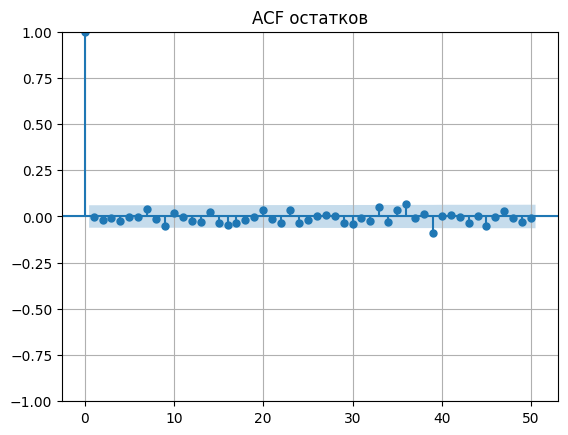

In [304]:
def check_autocorrelation(e, lags=50, m=1, alpha=0.05, plot=True):
    result = acorr_ljungbox(e, lags=lags, return_df=True, model_df=m)
    
    # Берем значения статистики и p-value на последнем лаге
    Q = result['lb_stat'].iloc[-1]
    df = max(lags - m, 1)
    p_value = 1 - stats.chi2.cdf(Q, df)

    print(f"Ljung–Box test :")
    print(f"Q = {Q:.3f} \ndf = {df} \np = {p_value:.4f}")
    if p_value < alpha:
        print("отклоняем H₀: присутствует автокорреляция остатков.")
    else:
        print("не отклоняем H₀: автокорреляция остатков не выявлена.")

    if plot:
        plot_acf(e, lags=lags)
        plt.title("ACF остатков")
        plt.grid(True)
        plt.show()

    return Q, p_value

m = X_with_const.shape[1]
Q, pval = check_autocorrelation(e, lags=50, m=m, alpha=alpha)


Критерий Пирсона–Фишера

Pearson–Fisher (нормальность): X² = 13.300, p = 0.0207
→ Отклоняем H₀: распределение ошибок отличается от нормального.


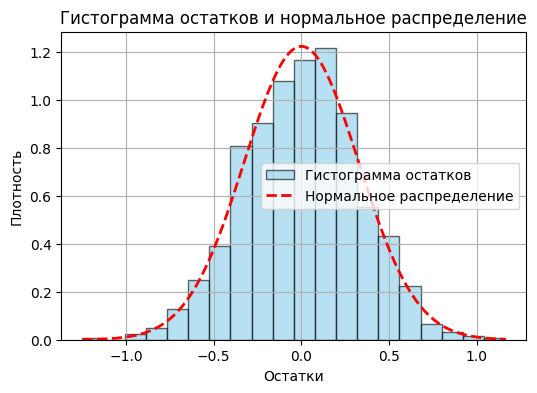

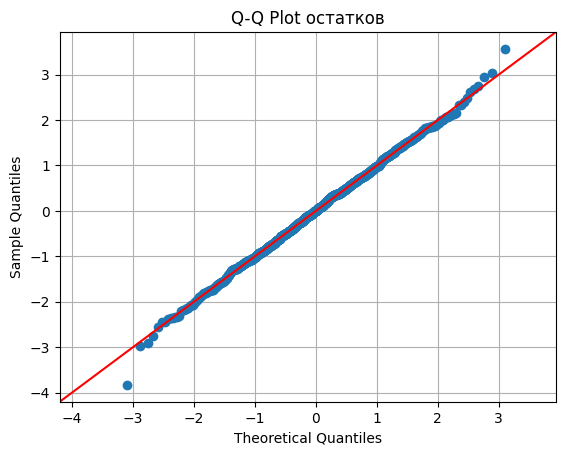

In [305]:
def pearson_fisher_test(e, m, k=20):
    n = len(e)
    e_std = e / np.std(e, ddof=int(m))
    hist, bin_edges = np.histogram(e_std, bins=k)
    pi = stats.norm.cdf(bin_edges[1:]) - stats.norm.cdf(bin_edges[:-1])
    expected = n * pi
    X = np.sum((hist - expected)**2 / expected)
    df = k - m - 2
    p_value = 1 - stats.chi2.cdf(X, df)
    return X, p_value

X_pf, p_pf = pearson_fisher_test(e, m)

print(f"Pearson–Fisher (нормальность): X² = {X_pf:.3f}, p = {p_pf:.4f}")
if p_pf < alpha:
    print("→ Отклоняем H₀: распределение ошибок отличается от нормального.")
else:
    print("→ Не отклоняем H₀: ошибки распределены нормально.\n")

# Оценка параметров нормального распределения
mu, sigma = np.mean(e), np.std(e)

# Значения для теоретической нормальной кривой
x_vals = np.linspace(min(e), max(e), 200)
normal_density = norm.pdf(x_vals, mu, sigma)

# Построение гистограммы остатков
plt.figure(figsize=(6, 4))
plt.hist(e, bins=20, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Гистограмма остатков')

# Построение кривой нормального распределения
plt.plot(x_vals, normal_density, 'r--', linewidth=2, label='Нормальное распределение')

# Оформление
plt.title("Гистограмма остатков и нормальное распределение")
plt.xlabel("Остатки")
plt.ylabel("Плотность")
plt.legend()
plt.grid(True)
plt.show()

sm.qqplot(e, line='45', fit=True)
plt.title("Q-Q Plot остатков")
plt.grid(True)
plt.show()